In [39]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict

In [40]:
#define class 
class BMI(TypedDict):
    weight: float
    height: float
    bmi: float 
    category : str 

In [41]:
#function calculate BMI 
def bmi_calculator(state: BMI) -> BMI:

    weight = state['weight']
    height = state['height']

    bmi = weight / (height **2 )

    #upate state 

    state['bmi'] = round(bmi, 2)

    return state



In [42]:
def bmi_cat(state: BMI) -> BMI:
    bmi = state['bmi']

    if bmi < 18.5 :
        state["category"] = 'Underweight'
    elif 18.5 <= bmi < 25 :
        state["category"] = 'Normal weight'
    elif 25 <= bmi < 30 :
        state["category"] = 'Overweight'
    else :
        state["category"] = 'Obesity'
    return state

In [43]:
#define graph

graph = StateGraph(BMI)

#define nodes

graph.add_node("Calculate BMI",bmi_calculator)
graph.add_node("Category " , bmi_cat)

#define edges 

graph.add_edge(START,"Calculate BMI")
graph.add_edge("Calculate BMI","Category ")
graph.add_edge("Category ",END)

#define complile 
workflow = graph.compile()

In [44]:
# execute workflow

initial_State = {"weight": 70.0, "height": 1.75}

final_State  = workflow.invoke(initial_State)

print(final_State)

{'weight': 70.0, 'height': 1.75, 'bmi': 22.86, 'category': 'Normal weight'}


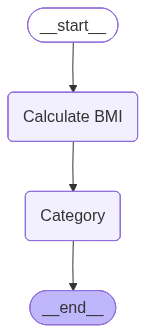

In [45]:
#visualize workflow
from IPython.display import Image 
Image(workflow.get_graph().draw_mermaid_png())